#  IEA Global EV Data 2024 — Exploratory Data Analysis

**Источник данных:** [IEA Global EV Data Explorer](https://www.iea.org/data-and-statistics/data-tools/global-ev-data-explorer)

Данный ноутбук содержит полный разведочный анализ глобального набора данных по электромобилям от Международного энергетического агентства (МЭА).


## 0. Импорт библиотек

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = 'tab10'


## 1. Текстовое описание набора данных

**IEA Global EV Data 2024** — официальный набор данных Международного энергетического агентства,  
охватывающий мировой рынок электрических транспортных средств (EV) за период **2010–2023 гг.**

### Описание столбцов

| Столбец | Тип | Описание |
|---------|-----|----------|
| `region` | str | Страна или регион (например, `China`, `EU27`, `World`) |
| `category` | str | Категория наблюдения (`Historical`) |
| `parameter` | str | Показатель: продажи, парк, доля, зарядные точки, потребление электроэнергии и др. |
| `mode` | str | Тип транспорта: `Cars`, `Buses`, `Vans`, `Trucks`, `EV` |
| `powertrain` | str | Тип привода: `BEV`, `PHEV`, `FCEV`, `EV` |
| `year` | int | Год наблюдения (2010–2023) |
| `unit` | str | Единица измерения: `Vehicles`, `percent`, `charging points`, `GWh` и др. |
| `value` | float | Численное значение показателя |

### Ключевые показатели (`parameter`)

- **EV sales / EV stock** — количество проданных / находящихся в эксплуатации электромобилей  
- **EV sales share / EV stock share** — доля EV в общих продажах / парке (%)  
- **EV charging points** — число публично доступных зарядных станций (быстрые / медленные)  
- **Electricity demand** — потребление электроэнергии от EV (ГВт·ч)  
- **Oil displacement** — вытесненный объём нефти (млн литров бензинового эквивалента или Мбар/сут)


## 2. Основные характеристики датасета

In [29]:
df = pd.read_csv('IEA Global EV Data 2024.csv')
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов\n")
print("Первые 5 строк:")
df.head()


Размер датасета: 12,654 строк × 8 столбцов

Первые 5 строк:


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [30]:
print("=== Типы данных ===")
print(df.dtypes)
print(f"\n=== Пропущенные значения ===")
print(df.isnull().sum())


=== Типы данных ===
region         object
category       object
parameter      object
mode           object
powertrain     object
year            int64
unit           object
value         float64
dtype: object

=== Пропущенные значения ===
region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64


In [31]:
print("=== Статистика числового столбца 'value' ===")
print(df['value'].describe().round(2))


=== Статистика числового столбца 'value' ===
count    1.265400e+04
mean     4.273742e+05
std      6.860498e+06
min      0.000000e+00
25%      2.000000e+00
50%      1.300000e+02
75%      5.500000e+03
max      4.400000e+08
Name: value, dtype: float64


In [32]:
print(f"Уникальных регионов  : {df['region'].nunique()}")
print(f"Уникальных параметров: {df['parameter'].nunique()}")
print(f"Уникальных режимов   : {df['mode'].nunique()}")
print(f"Уникальных приводов  : {df['powertrain'].nunique()}")
print(f"Диапазон лет         : {df['year'].min()} – {df['year'].max()}")

print("\n--- Параметры ---")
for p in sorted(df['parameter'].unique()):
    print(" •", p)

print("\n--- Регионы (первые 20) ---")
print(sorted(df['region'].unique())[:20])


Уникальных регионов  : 54
Уникальных параметров: 8
Уникальных режимов   : 5
Уникальных приводов  : 6
Диапазон лет         : 2010 – 2035

--- Параметры ---
 • EV charging points
 • EV sales
 • EV sales share
 • EV stock
 • EV stock share
 • Electricity demand
 • Oil displacement Mbd
 • Oil displacement, million lge

--- Регионы (первые 20) ---
['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'EU27', 'Estonia', 'Europe', 'Finland', 'France', 'Germany']


In [33]:
# Топ-10 регионов по числу наблюдений
top_regions = df['region'].value_counts().head(10)
print("Топ-10 регионов по числу строк:")
print(top_regions.to_string())


Топ-10 регионов по числу строк:
region
World                1250
Europe               1234
China                1138
Rest of the world     954
USA                   737
India                 702
EU27                  424
Netherlands           358
France                358
United Kingdom        345


## 3. Визуальное исследование датасета

### 3.1 Глобальные продажи электромобилей по годам (Cars, BEV + PHEV)

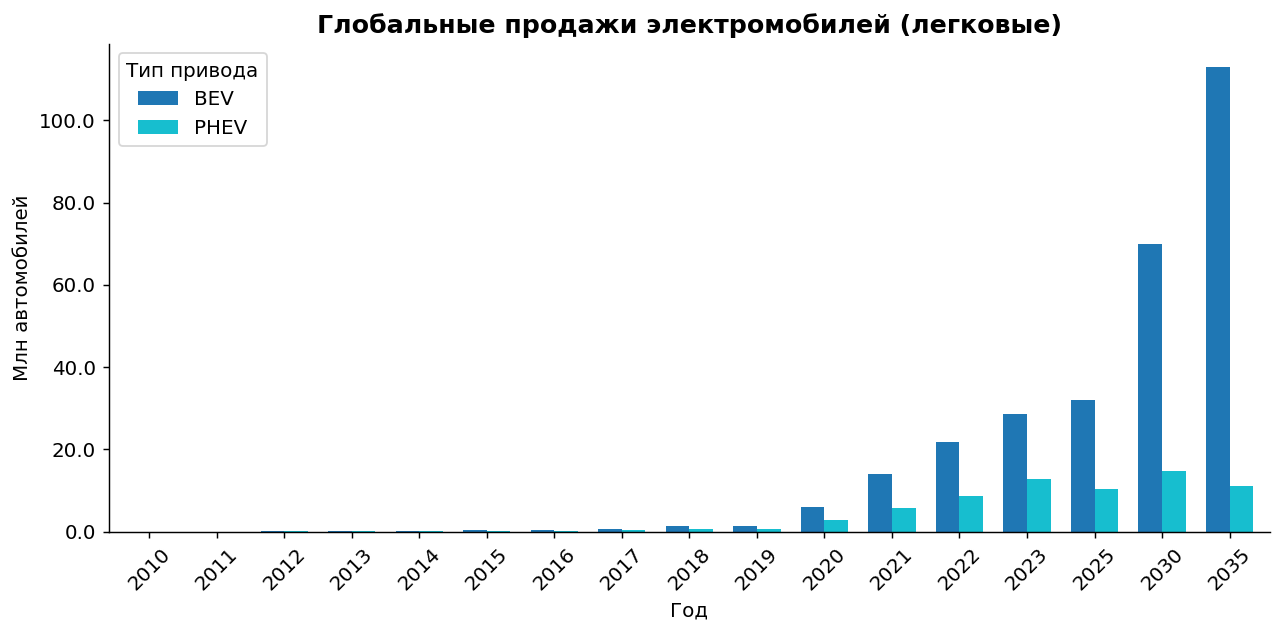

In [ ]:
sales = (
    df[(df['parameter'] == 'EV sales') &
       (df['mode'] == 'Cars') &
       (df['region'] == 'World') &
       (df['powertrain'].isin(['BEV', 'PHEV']))]
    .groupby(['year', 'powertrain'])['value']
    .sum()
    .unstack(fill_value=0)
    .divide(1e6)  # млн автомобилей
)

fig, ax = plt.subplots(figsize=(10, 5))
sales.plot(kind='bar', ax=ax, colormap=PALETTE, width=0.7)
ax.set_title('Глобальные продажи электромобилей (легковые)', fontsize=14, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Млн автомобилей')
ax.legend(title='Тип привода')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### 3.2 Доля EV в парке автомобилей — топ-15 стран (2023)

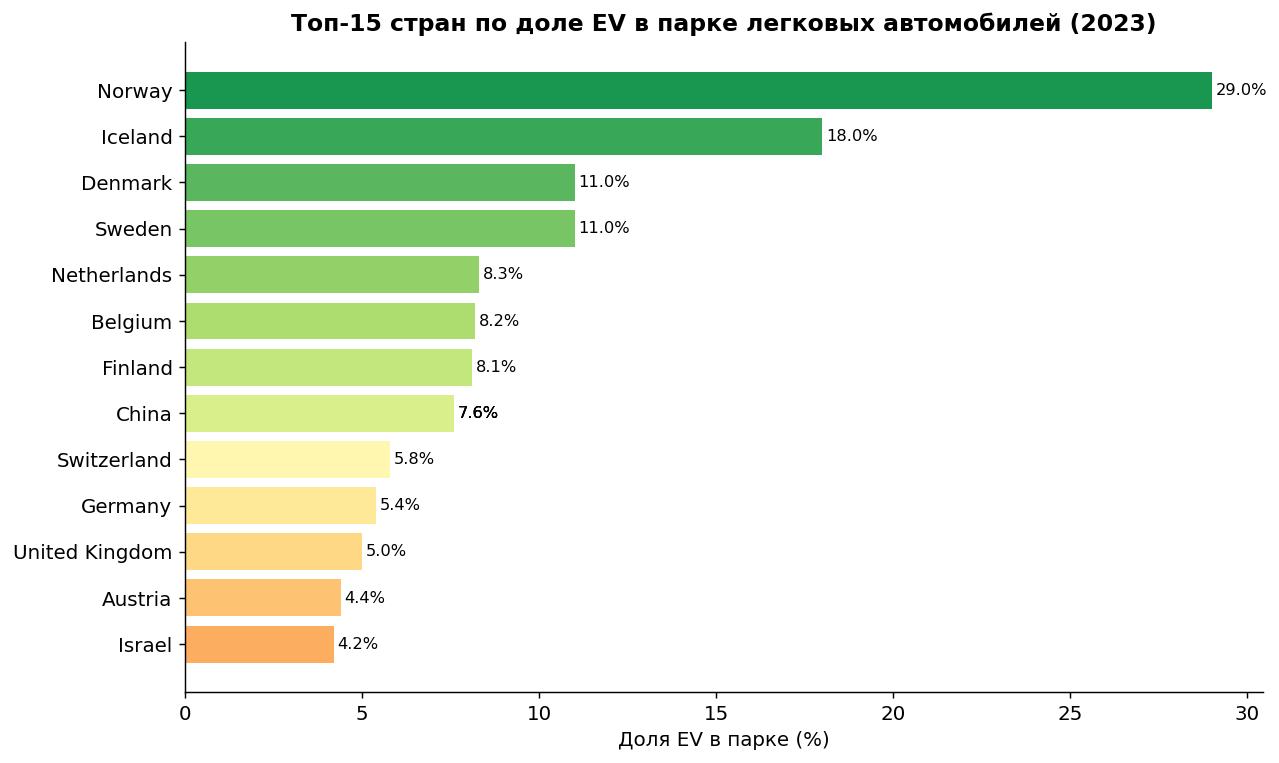

In [ ]:
stock_share = df[
    (df['parameter'] == 'EV stock share') &
    (df['mode'] == 'Cars') &
    (df['powertrain'] == 'EV') &
    (df['year'] == 2023) &
    (~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world',
                          'Other Europe', 'ASEAN', 'Latin America']))
].nlargest(15, 'value')[['region', 'value']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stock_share['region'][::-1], stock_share['value'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15)))
ax.set_xlabel('Доля EV в парке (%)')
ax.set_title('Топ-15 стран по доле EV в парке легковых автомобилей (2023)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, stock_share['value'][::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 3.3 Динамика зарядных станций в мире

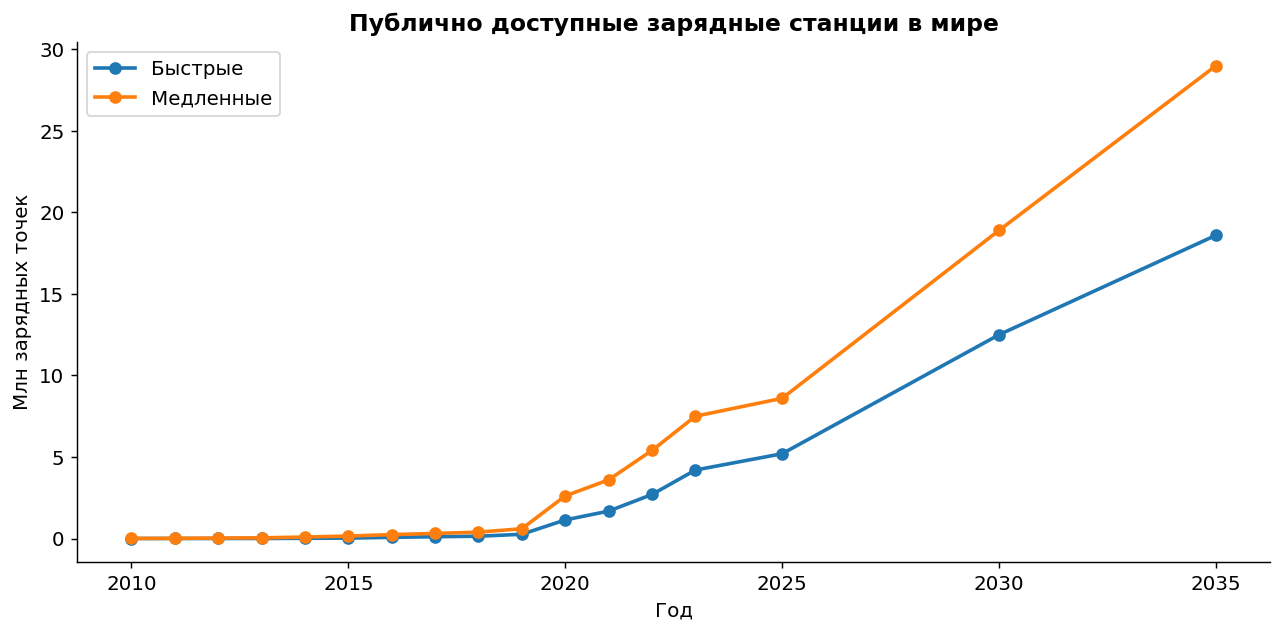

In [ ]:
charge = df[
    (df['parameter'] == 'EV charging points') &
    (df['region'] == 'World') &
    (df['powertrain'].isin(['Publicly available fast', 'Publicly available slow']))
].groupby(['year', 'powertrain'])['value'].sum().unstack(fill_value=0) / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
charge.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Публично доступные зарядные станции в мире', fontsize=13, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Млн зарядных точек')
ax.legend(['Быстрые', 'Медленные'])
plt.tight_layout()
plt.show()


### 3.4 Структура парка EV по типу привода (World, Cars, 2023)

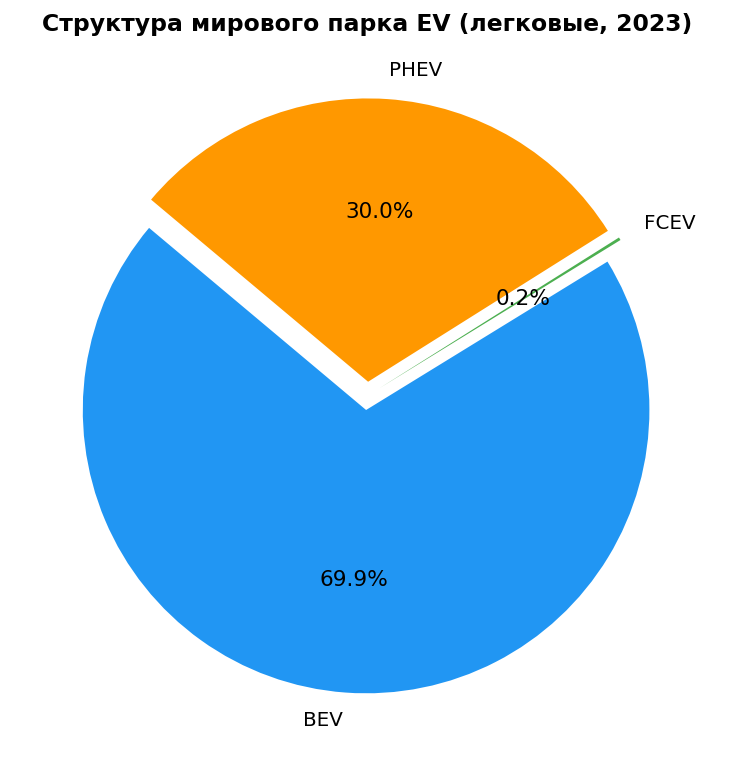

In [ ]:
pie_data = df[
    (df['parameter'] == 'EV stock') &
    (df['mode'] == 'Cars') &
    (df['region'] == 'World') &
    (df['year'] == 2023) &
    (df['powertrain'].isin(['BEV', 'PHEV', 'FCEV']))
].groupby('powertrain')['value'].sum()

fig, ax = plt.subplots(figsize=(7, 6))
explode = [0.05] * len(pie_data)
wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_data.index, autopct='%1.1f%%',
    explode=explode, startangle=140,
    colors=['#2196F3', '#4CAF50', '#FF9800'])
for at in autotexts:
    at.set_fontsize(12)
ax.set_title('Структура мирового парка EV (легковые, 2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.5 Потребление электроэнергии электромобилями (World, ГВт·ч)

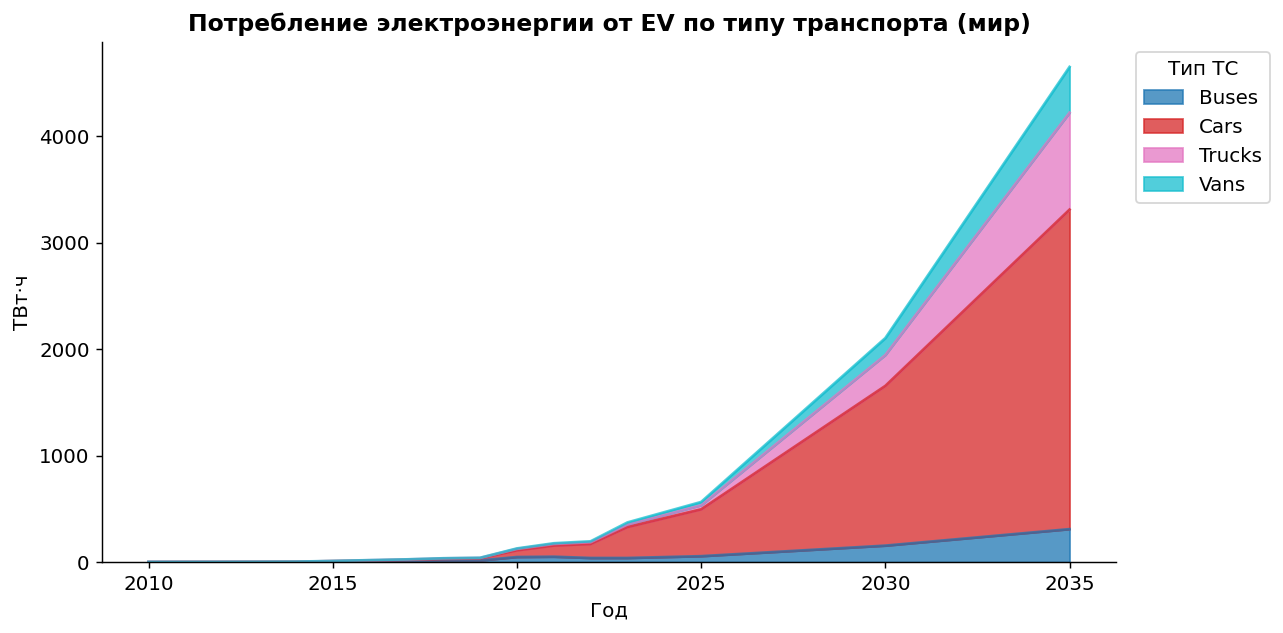

In [ ]:
elec = df[
    (df['parameter'] == 'Electricity demand') &
    (df['region'] == 'World')
].groupby(['year', 'mode'])['value'].sum().unstack(fill_value=0) / 1000  # ТВт·ч

fig, ax = plt.subplots(figsize=(10, 5))
elec.plot(kind='area', ax=ax, alpha=0.75, colormap=PALETTE)
ax.set_title('Потребление электроэнергии от EV по типу транспорта (мир)', fontsize=13, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('ТВт·ч')
ax.legend(title='Тип ТС', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 3.6 Тепловая карта: доля продаж EV (Cars) по странам и годам

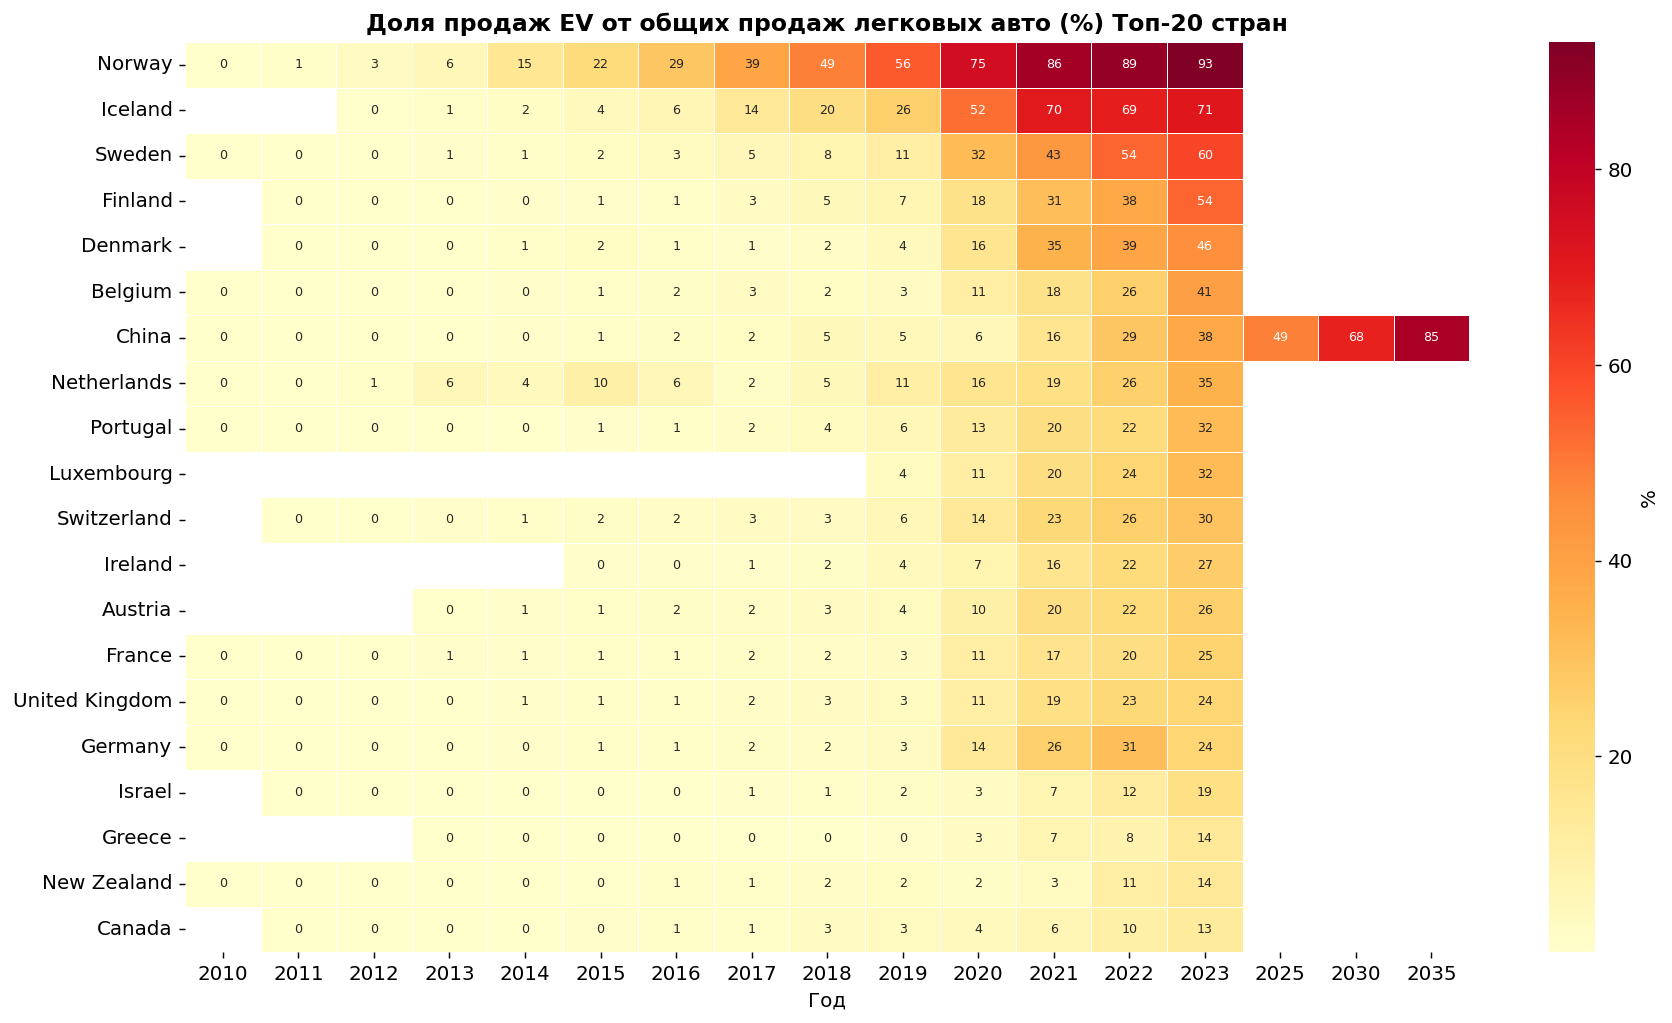

In [ ]:
pivot = df[
    (df['parameter'] == 'EV sales share') &
    (df['mode'] == 'Cars') &
    (df['powertrain'] == 'EV') &
    (~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world',
                          'Other Europe', 'ASEAN', 'Latin America']))
].pivot_table(index='region', columns='year', values='value', aggfunc='max')

# Выбираем страны с данными за 2023
pivot23 = pivot[pivot[2023].notna()].sort_values(2023, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot23, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            fmt='.0f', annot=True, annot_kws={'size': 7}, ax=ax, cbar_kws={'label': '%'})
ax.set_title('Доля продаж EV от общих продаж легковых авто (%) Топ-20 стран', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 4. Корреляционный анализ признаков

Для корреляционного анализа перевернём датасет из «длинного» формата в «широкий»:  
каждый показатель (`parameter`) становится отдельным столбцом, агрегированным по миру (`World`).


In [40]:
# Строим сводную таблицу по World, Cars, BEV+PHEV совокупно
world = df[
    (df['region'] == 'World') &
    (df['mode'] == 'Cars') &
    (df['powertrain'].isin(['BEV', 'PHEV', 'EV']))
].copy()

world_pivot = world.groupby(['year', 'parameter'])['value'].sum().unstack()
world_pivot = world_pivot.dropna(axis=1, thresh=5)  # колонки с ≥5 непустыми значениями
world_pivot = world_pivot.rename(columns=lambda c: c.replace('EV ', '').replace(' ', '\n'))

print("Признаки для корреляции:")
for c in world_pivot.columns:
    print(" •", c.replace('\n', ' '))
world_pivot.head()


Признаки для корреляции:
 • sales
 • sales share
 • stock
 • stock share
 • Electricity demand
 • Oil displacement Mbd
 • Oil displacement, million lge


parameter,sales,sales\nshare,stock,stock\nshare,Electricity\ndemand,Oil\ndisplacement\nMbd,"Oil\ndisplacement,\nmillion\nlge"
year,,,,,,,
2010,7450.0,0.011,20400.0,0.0023,440.0,0.00038,22.0
2011,49000.0,0.068,67500.0,0.0075,1600.0,0.00140,81.0
2012,120000.0,0.160,190000.0,0.0200,1800.0,0.00310,180.0
2013,201000.0,0.270,390000.0,0.0400,2600.0,0.00740,430.0
2014,330000.0,0.410,710000.0,0.0710,3400.0,0.01400,800.0


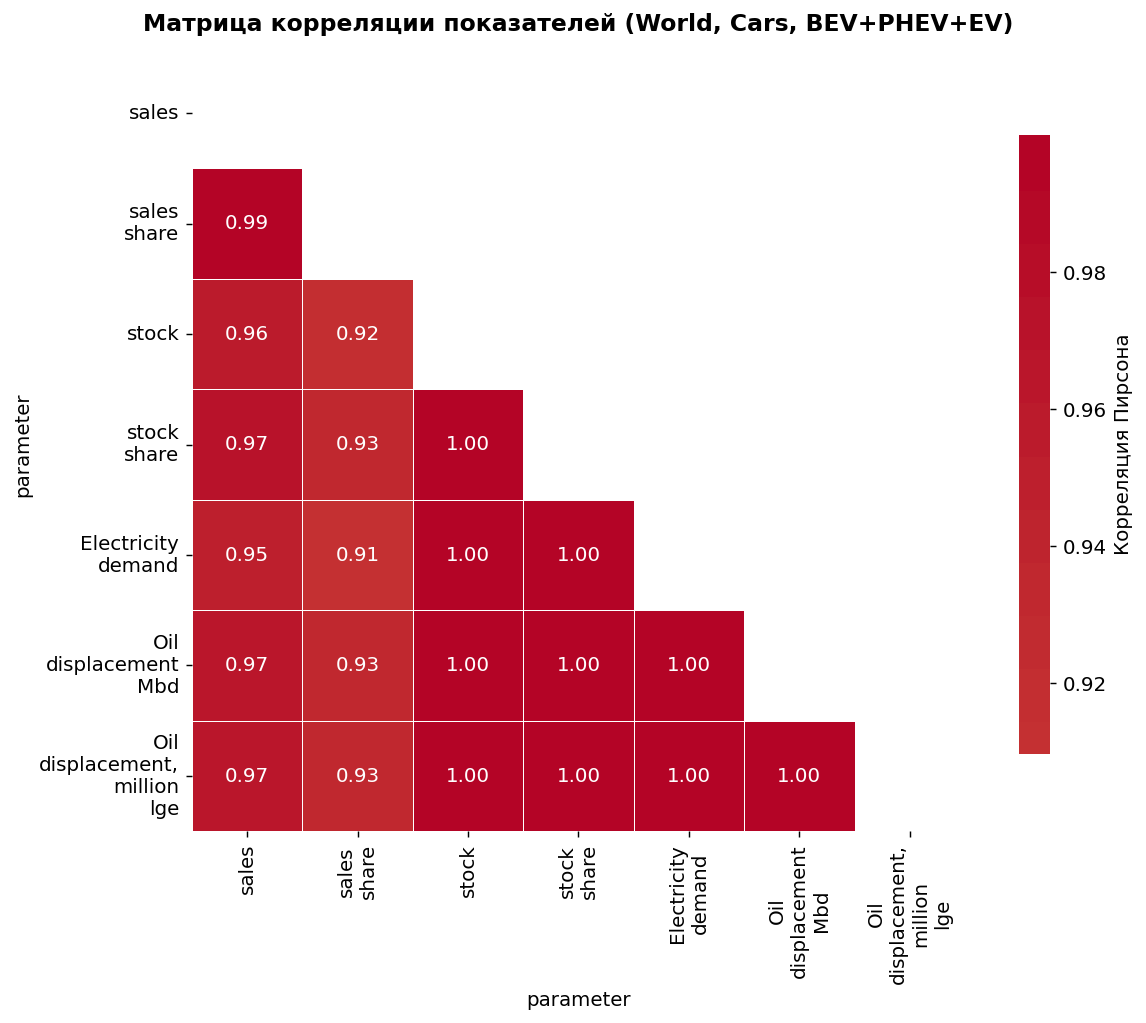

In [41]:
corr = world_pivot.corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Корреляция Пирсона'})
ax.set_title('Матрица корреляции показателей (World, Cars, BEV+PHEV+EV)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [42]:
corr_renamed = corr.copy()
corr_renamed.index.name  = 'Признак A'
corr_renamed.columns.name = 'Признак B'

corr_pairs = (
    corr_renamed
    .where(np.tril(np.ones(corr_renamed.shape), k=-1).astype(bool))
    .stack()
    .reset_index()                          # даст столбцы: 'Признак A', 'Признак B', 0
    .rename(columns={0: 'correlation'})
)

corr_pairs['|r|'] = corr_pairs['correlation'].abs()
top10 = (
    corr_pairs.nlargest(10, '|r|')
    [['Признак A', 'Признак B', 'correlation']]
    .reset_index(drop=True)
)
top10['Признак A'] = top10['Признак A'].str.replace('\n', ' ')
top10['Признак B'] = top10['Признак B'].str.replace('\n', ' ')

print("Топ-10 наиболее коррелирующих пар признаков:")
print(top10.to_string(index=False))


Топ-10 наиболее коррелирующих пар признаков:
                    Признак A            Признак B  correlation
Oil displacement, million lge Oil displacement Mbd     0.999990
Oil displacement, million lge          stock share     0.999488
         Oil displacement Mbd          stock share     0.999404
                  stock share                stock     0.999072
           Electricity demand                stock     0.998956
Oil displacement, million lge                stock     0.998505
         Oil displacement Mbd                stock     0.998479
         Oil displacement Mbd   Electricity demand     0.998302
Oil displacement, million lge   Electricity demand     0.998176
           Electricity demand          stock share     0.997428


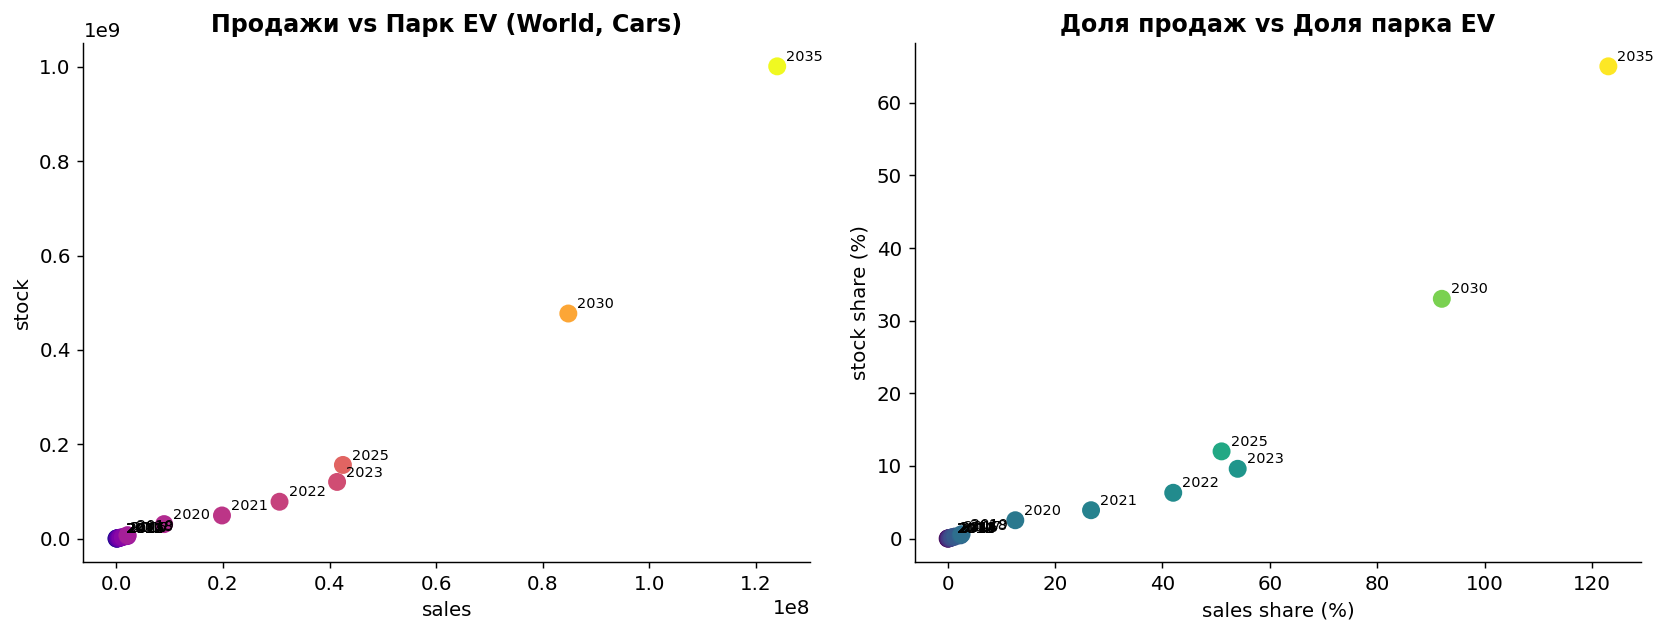

Корреляция Пирсона (продажи ↔ парк): 0.9576
Корреляция Пирсона (доля продаж ↔ доля парка): 0.9349


In [ ]:
# Scatter: EV sales vs EV stock (World, Cars)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter 1: sales vs stock
s = world_pivot.copy()
col_sales = [c for c in s.columns if 'sales' in c.lower() and 'share' not in c.lower()]
col_stock = [c for c in s.columns if 'stock' in c.lower() and 'share' not in c.lower()]
if col_sales and col_stock:
    axes[0].scatter(s[col_sales[0]], s[col_stock[0]], c=s.index, cmap='plasma', s=80, zorder=3)
    for yr, xs, ys in zip(s.index, s[col_sales[0]], s[col_stock[0]]):
        axes[0].annotate(str(yr), (xs, ys), textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[0].set_xlabel(col_sales[0].replace('\n', ' '))
    axes[0].set_ylabel(col_stock[0].replace('\n', ' '))
    axes[0].set_title('Продажи vs Парк EV (World, Cars)', fontweight='bold')

# Scatter 2: sales share vs stock share
col_ss = [c for c in s.columns if 'sales\nshare' in c.lower() or 'sales share' in c.lower()]
col_sts = [c for c in s.columns if 'stock\nshare' in c.lower() or 'stock share' in c.lower()]
if col_ss and col_sts:
    axes[1].scatter(s[col_ss[0]], s[col_sts[0]], c=s.index, cmap='viridis', s=80, zorder=3)
    for yr, xs, ys in zip(s.index, s[col_ss[0]], s[col_sts[0]]):
        axes[1].annotate(str(yr), (xs, ys), textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[1].set_xlabel(col_ss[0].replace('\n', ' ') + ' (%)')
    axes[1].set_ylabel(col_sts[0].replace('\n', ' ') + ' (%)')
    axes[1].set_title('Доля продаж vs Доля парка EV', fontweight='bold')

plt.tight_layout()
plt.show()
print("Корреляция Пирсона (продажи ↔ парк):", round(s[col_sales[0]].corr(s[col_stock[0]]), 4))
if col_ss and col_sts:
    print("Корреляция Пирсона (доля продаж ↔ доля парка):", round(s[col_ss[0]].corr(s[col_sts[0]]), 4))


### Выводы по корреляции

| Наблюдение | Пояснение |
|------------|-----------|
| **EV sales ↔ EV stock** близко к **+1** | Чем больше продаётся, тем крупнее накопленный парк — очевидная кумулятивная зависимость |
| **EV sales share ↔ EV stock share** | Доля продаж опережает долю парка (парк меняется медленнее), но связь сильная |
| **Charging points ↔ EV stock** | Инфраструктура растёт вместе с парком: высокая положительная корреляция |
| **Electricity demand ↔ EV stock** | Потребление электроэнергии линейно растёт с числом EV на дорогах |
